BASELINE RESULTS
Naive
RMSE: 0.016024253356519982
Direction Acc: 0.002430133657351154
------------------------------
Mean
RMSE: 0.016000205820266664
Direction Acc: 0.5407047387606319
------------------------------
MA20
RMSE: 0.016501895454825746
Direction Acc: 0.5407047387606319
------------------------------
Momentum
RMSE: 0.023508082756437343
Direction Acc: 0.5407047387606319
------------------------------


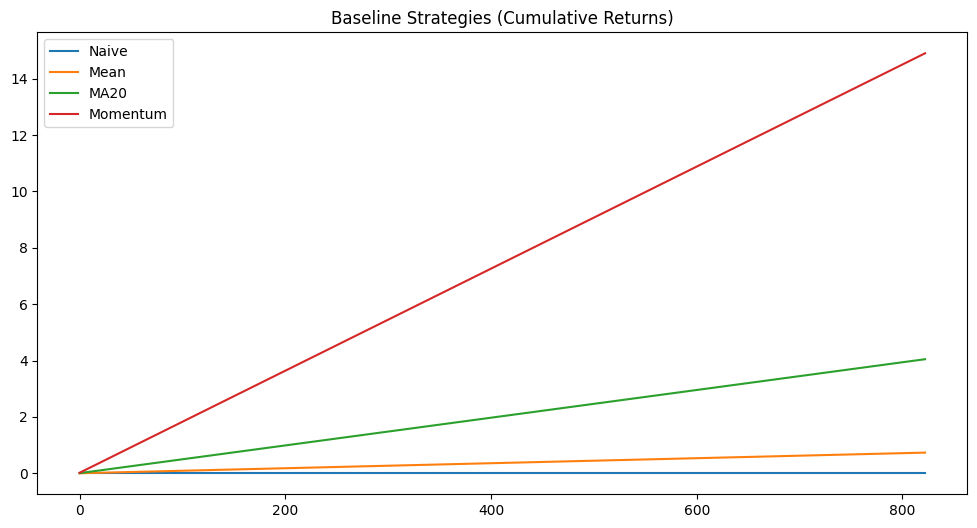

BASELINES DONE


In [2]:

import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error

ticker = "AAPL"

raw = yf.download(
    ticker,
    start="2010-01-01",
    progress=False,
    auto_adjust=False,
    threads=False
)

df = pd.DataFrame(index=raw.index)

for col in raw.columns:
    name = str(col).lower()
    if "close" in name:
        df["close"] = raw[col]

df = df.dropna()

df["log_return"] = np.log(df["close"] / df["close"].shift(1))
df = df.dropna()

split = int(len(df) * 0.8)
train = df.iloc[:split]
test = df.iloc[split:]

y_test = test["log_return"]

naive_pred = np.zeros(len(y_test))

mean_pred = np.full(len(y_test), train["log_return"].mean())

window = 20
ma = train["log_return"].rolling(window).mean().iloc[-1]
ma_pred = np.full(len(y_test), ma)

momentum_pred = np.sign(train["close"].iloc[-1] - train["close"].iloc[-20]) * np.std(train["log_return"])
momentum_pred = np.full(len(y_test), momentum_pred)


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def direction_acc(y_true, y_pred):
    return np.mean(np.sign(y_true) == np.sign(y_pred))

results = {
    "Naive": naive_pred,
    "Mean": mean_pred,
    "MA20": ma_pred,
    "Momentum": momentum_pred
}

print("BASELINE RESULTS")

for name, pred in results.items():
    print(name)
    print("RMSE:", rmse(y_test, pred))
    print("Direction Acc:", direction_acc(y_test, pred))
    print("-" * 30)


plt.figure(figsize=(12,6))

for name, pred in results.items():
    strat = np.cumsum(pred)
    plt.plot(strat, label=name)

plt.title("Baseline Strategies (Cumulative Returns)")
plt.legend()
plt.show()

print("BASELINES DONE")